# Abstract Classification
In this notebook we aim to develop a classification model regarding NLP. Our goal is to predict whether a given paper abstract concerns about Machine Learning.

In [ ]:
import pandas as pd
import numpy as np
import nltk
from datetime import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import functions_aux as f
from sklearn.metrics import classification_report
from joblib import dump, load

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='white')

# magic command to reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
brz_path = 'bronze'
df = pd.read_json(f'{brz_path}/classified_abstracts.json')
df

,DOI,Abstract,Label
0,10.1155/2021/1071145,Forward-looking forecasting of the inflation r...,1
1,10.1007/s43546-022-00384-2,Our study examined the disaggregation of infla...,1
2,10.1002/for.2667,This paper develops a dynamic factor model tha...,0
3,10.1007/s42973-021-00091-x,"In this paper, I use a simple SIR Macro model ...",0
4,10.1007/s40258-012-0003-z,BackgroundGame theory is useful for identifyin...,0
...,...,...,...
1133,10.1007/bf00123887,Concluding remarksWhile the final version of t...,0
1134,10.1093/acrefore/9780190625979.013.171,High-Dimensional Dynamic Factor Models have th...,0
1135,10.1287/mnsc.2013.1812,"Francesca Gino, Erin L. Krupka, Roberto A. Web...",0
1136,10.2118/22022-pa,"Summary EOR projects, notably CO2 floods, are ...",0


## EDA and Feature Engineering
Firstly, we observe four duplicates and 1 missing value in DOI. We remove them all.

In [3]:
df = df.drop_duplicates(subset='DOI')
df.isnull().sum()

DOI         1
Abstract    0
Label       0
dtype: int64

In [4]:
df = df[~df['DOI'].isna()]

In [12]:
aux = df['Label'].value_counts()
display(aux)

display(aux / len(df))

Label
0    900
1    234
Name: count, dtype: int64

Label
0    0.793651
1    0.206349
Name: count, dtype: float64

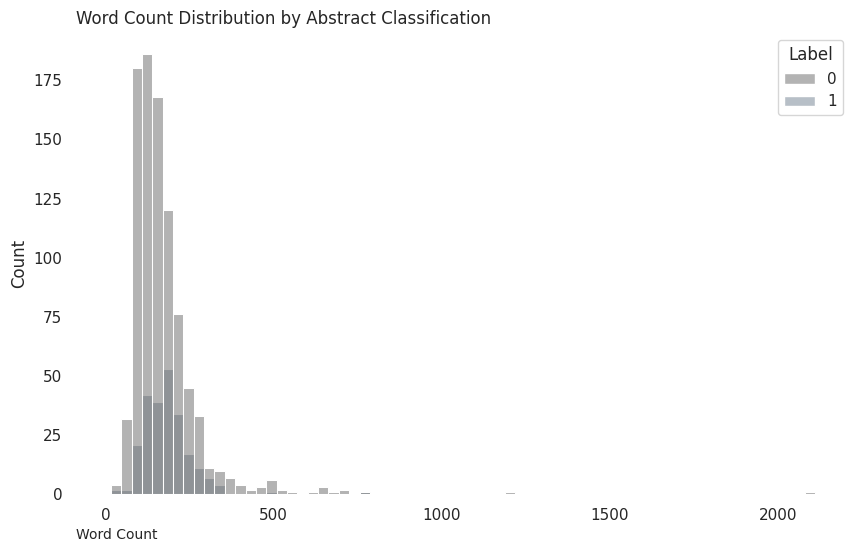

In [5]:
df['n_chars'] = df['Abstract'].str.len()  # number of characters, including blank space
df['word_count'] = df['Abstract'].str.split(' ').str.len()  # word count
df['Abstract'] = df['Abstract'].str.lower()


plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x='word_count',
    hue='Label',
    palette=['dimgrey', 'slategrey']
)
plt.title(
    'Word Count Distribution by Abstract Classification',
    loc='left',
    fontsize=12
)
plt.xlabel('Word Count', loc='left', fontsize=10)
plt.box(False)

## Baseline
As an immediate baseline, we can simply check if the abstract contains the string 'machine learning' and predict it as 1 if positive and 0 if negative. This way, we get 64 out of 234.

In [6]:
df['contains_ML'] = df['Abstract']\
    .str.contains('machine learning')\
    .astype(int)

df[['contains_ML', 'Label']].groupby('Label').sum()

,contains_ML
Label,
0,0
1,64


As we are dealing with a classification problem, it is interesting to consider metrics from the consufion matrix, such as recall, precision, F1, and accuracy. Particularly, since we have an imbalanced dataset (20% of positive values), we shall pay more attention to metrics that give more weight to the positive class, like precision, recall, and F1 score. Below is the confusion metrics for our baseline.

In [23]:
cnfn_metrics = {}
cnfn_metrics['baseline'] = f.get_confusion_metrics(df, 'Label', 'contains_ML')
cnfn_metrics

{'baseline': {'tpr': np.float64(0.27350427350427353),
  'tnr': np.float64(1.0),
  'fpr': np.float64(0.0),
  'fnr': np.float64(0.7264957264957265),
  'npv': np.float64(0.8411214953271028),
  'acc': np.float64(0.8500881834215167),
  'ppv': np.float64(1.0),
  'f1': np.float64(0.4295302013422819)}}

From them, we get:

1. Only 27% of actual positives were caught (TPR, also known as recall)
2. We never misclassified a negative as positive (TNR, also known as specificity)
3. No false positives (FPR; consistent with the keyword being overly strict)
4. Every positive we predicted really is one (PPV, also known as precision)
5. Good accuracy, but is inflated by class imbalance (many negatives)
6. 43% of F1 score reflects the precision x recall trade-off, where low recall drags it down

The considerations above suggest that many abstracts refer to the positive class implicitly, through synonyms, like deep learning, artificial intelligence, predictive model, or related phrasing. We can thus extend our baseline to include such synonyms or related keywords.

### Stronger Baseline

In [74]:
df['contains_DL'] = df['Abstract']\
    .str.contains('deep learning')\
    .astype(int)

df['contains_NN'] = df['Abstract']\
    .str.contains('neural network')\
    .astype(int)

df['contains_AI'] = df['Abstract']\
    .str.contains('artificial intelligence')\
    .astype(int)

df['contains_PM'] = df['Abstract']\
    .str.contains('predictive model')\
    .astype(int)

df['baseline_pred'] = (
    df[[
        'contains_ML', 'contains_DL',
        'contains_NN', 'contains_AI',
        'contains_PM'
    ]].any(axis=1)
).astype(int)

df.head()

,DOI,Abstract,Label,n_chars,word_count,contains_ML,contains_DL,contains_NN,contains_AI,contains_PM,baseline_pred
0,10.1155/2021/1071145,forward-looking forecasting of the inflation r...,1,1502,211,0,1,1,0,1,1
1,10.1007/s43546-022-00384-2,our study examined the disaggregation of infla...,1,1218,188,1,0,0,0,0,1
2,10.1002/for.2667,this paper develops a dynamic factor model tha...,0,1083,156,0,0,0,0,0,0
3,10.1007/s42973-021-00091-x,"in this paper, i use a simple sir macro model ...",0,1251,194,0,0,0,0,0,0
4,10.1007/s40258-012-0003-z,backgroundgame theory is useful for identifyin...,0,1576,209,0,0,0,0,0,0


In [77]:
cnfn_metrics['baseline'] = f.get_confusion_metrics(df, 'Label', 'baseline_pred')
cnfn_metrics

{'baseline': {'tpr': np.float64(0.47863247863247865),
  'tnr': np.float64(0.9955555555555555),
  'fpr': np.float64(0.0044444444444444444),
  'fnr': np.float64(0.5213675213675214),
  'npv': np.float64(0.8801571709233792),
  'acc': np.float64(0.8888888888888888),
  'ppv': np.float64(0.9655172413793104),
  'f1': np.float64(0.64)}}

These new numbers show that nearly twice as many true positives are being caught (21 percentage points increase on TPR) with nearly perfect precision (97% of PPV). The former results on a massive gain on F1 score: 64%.

This demonstrates that many relevant abstracts do not mention Machine Learning directly, but use related phrases. As FPR remains practically 0, our keywords show to be precise. In other words, still, we are now retrieving half of all true positives, with almost perfect precision. Our learned model now has a great baseline to beat.

## Pipeline with CountVectorizer

In [26]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

### Train/Validation/Test Split
We will split our dataset into 70%/15%/15%. As `train_test_split` only divides into two parts each time, we will create the splits in two stages. The first will split the 100% dataset into 85%/15%: 15% for the test set, `X_test` and `y_test`, and the remaining 85% into a temporary dataset, `X_temp`, `y_temp`, later to be spllited once again into the training and validation sets. Consider, however, that in order to obtain 15% of the *total* dataset, we must evaluate the new splitting ratio: $0.85x = 0.15$, to be $x \approx$ 0.1765. Therefore, we split `X_temp` and `y_temp` into two, training and validation sets, with `test_size` = 0.1765.

In [27]:
X = df['Abstract'].copy()
y = df['Label'].copy()


SEED = 1

# keep a holdout test set for final evaluation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED
)

# use the remaining for training + CV
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=SEED
)

print(f'Training set size: {len(X_train)}')
print(f'Validation set size: {len(X_val)}')
print(f'Test set size: {len(X_test)}')

Training set size: 793
Validation set size: 170
Test set size: 171


### Pipeline, CV and GridSearchCV

In [16]:
pipeline = Pipeline([
    ('vect', CountVectorizer()),
    ('clf', LogisticRegression(random_state=SEED, class_weight='balanced'))
])

param_grid = {
    'vect__ngram_range': [(1,1), (1,2)],          # unigrams or up to bigrams
    'vect__min_df': [1, 2, 5],                    # drop very rare tokens
    'vect__max_df': [0.9, 0.95, 1.0],             # drop very frequent tokens (as fraction)
    'vect__max_features': [10000, 30000, None],   # limit vocab size
    'vect__binary': [False, True],                # use presence/absence vs counts
    'clf__C': [0.1, 1.0, 5.0],                    # regularization inverse strength
    'clf__solver': ['liblinear', 'saga', 'lbfgs'] # optimization algorithm
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

,estimator,Pipeline(step...om_state=1))])
,param_grid,"{'clf__C': [0.1, 1.0, ...], 'clf__solver': ['liblinear', 'saga', ...], 'vect__binary': [False, True], 'vect__max_df': [0.9, 0.95, ...], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [17]:
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best params: {'clf__C': 1.0, 'clf__solver': 'liblinear', 'vect__binary': True, 'vect__max_df': 1.0, 'vect__max_features': 10000, 'vect__min_df': 2, 'vect__ngram_range': (1, 1)}
Best CV F1: 0.7423237054384595


In [66]:
# best = grid.best_estimator_

# model_path = 'models'
# dump(best, f'{model_path}/lr.pkl')

model_path = 'models'
lr = load(f'{model_path}/lr.pkl')

In [68]:
cnfn_metrics

{'baseline': {'tpr': np.float64(0.47863247863247865),
  'tnr': np.float64(0.9977777777777778),
  'fpr': np.float64(0.0022222222222222222),
  'fnr': np.float64(0.5213675213675214),
  'npv': np.float64(0.8803921568627451),
  'acc': np.float64(0.890652557319224),
  'ppv': np.float64(0.9824561403508771),
  'f1': np.float64(0.6436781609195402)}}

In [ ]:
y_pred = lr.predict(X_val)

df_val = df.iloc[X_val.index]
df_val['pred_val'] = y_pred

cnfn_metrics['lr_val'] = f.get_confusion_metrics(df_val, 'Label', 'pred_val')

y_pred = lr.predict(X_test)

df_test = df.iloc[X_test.index]
df_test['pred_test'] = y_pred

cnfn_metrics['lr_test'] = f.get_confusion_metrics(df_test, 'Label', 'pred_test')

In [70]:
cnfn_metrics

{'baseline': {'tpr': np.float64(0.47863247863247865),
  'tnr': np.float64(0.9977777777777778),
  'fpr': np.float64(0.0022222222222222222),
  'fnr': np.float64(0.5213675213675214),
  'npv': np.float64(0.8803921568627451),
  'acc': np.float64(0.890652557319224),
  'ppv': np.float64(0.9824561403508771),
  'f1': np.float64(0.6436781609195402)},
 'lr_val': {'tpr': np.float64(0.14285714285714285),
  'tnr': np.float64(0.837037037037037),
  'fpr': np.float64(0.16296296296296298),
  'fnr': np.float64(0.8571428571428571),
  'npv': np.float64(0.7902097902097902),
  'acc': np.float64(0.6941176470588235),
  'ppv': np.float64(0.18518518518518517),
  'f1': np.float64(0.16129032258064516)},
 'lr_test': {'tpr': np.float64(0.08571428571428572),
  'tnr': np.float64(0.7941176470588235),
  'fpr': np.float64(0.20588235294117646),
  'fnr': np.float64(0.9142857142857143),
  'npv': np.float64(0.7714285714285715),
  'acc': np.float64(0.6491228070175439),
  'ppv': np.float64(0.0967741935483871),
  'f1': np.float